# Notebook 05 — Segmentación de pacientes

Agrupa las citas en perfiles de riesgo y accionabilidad para responder a una
pregunta de negocio: **¿es óptimo enviar el SMS a toda la agenda por igual, o conviene
priorizar?** La segmentación se apoya en la probabilidad de no-show calibrada del modelo
predictivo (Notebook 03) y en variables operativas de la cita procedentes de la limpieza
(Notebook 01).

El clustering vive sobre el conjunto de **test** (las citas con probabilidad calibrada
fuera de muestra), de modo que los perfiles se construyen sobre estimaciones de riesgo
honestas y no sobre ajuste en muestra.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import logging
from src import segmentacion as seg, rutas

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
seg.configurar_estilo()
np.random.seed(seg.SEED)

## 1. Carga y unión de datos

Se unen por `AppointmentID` dos fuentes: la probabilidad de no-show calibrada (Notebook 03) y
las covariables operativas de la cita (limpieza del Notebook 01). El resultado son las citas de
test con todo lo necesario para segmentar y, después, perfilar.

In [2]:
df = seg.cargar_datos_segmentacion(
    rutas.REPORTES / "noshow_probs_v1.csv",
    rutas.CSV_FULL_CLEAN,
)
print(f"Citas: {len(df):,}  |  pacientes únicos: {df['PatientId'].nunique():,}")
df[["prob_noshow_calibrada", "lead_time_bin", "is_first_visit",
    "neighbourhood_encoded", "SMS_received", "Showed_up"]].head()

18:41:39 [INFO] Datos de segmentación: 21330 citas (test), 17648 pacientes únicos.


Citas: 21,330  |  pacientes únicos: 17,648


,prob_noshow_calibrada,lead_time_bin,is_first_visit,neighbourhood_encoded,SMS_received,Showed_up
0,0.256749,15+d,1,0.025380,False,0
1,0.319955,15+d,1,0.025380,True,1
2,0.478070,15+d,1,0.025380,True,1
3,0.319042,15+d,1,0.025380,True,1
4,0.025196,mismo_dia,1,0.017407,False,1


## 2. Variables de segmentación

El clustering usa un conjunto **compacto** de cuatro variables que combinan dos ejes distintos:

- **probabilidad de no-show calibrada** (Notebook 03) — el eje de **riesgo**: resume en un solo
  número el ranking de riesgo de la cita;
- **antelación (bin ordinal)** — mismo día → 1-7 d → 8-14 d → 15+ d;
- **barrio (codificación por frecuencia)** — proxy socioeconómico/geográfico;
- **primera visita observada** — paciente nuevo vs recurrente.

Las tres últimas son ejes de **accionabilidad operativa** (cuándo, dónde y a quién intervenir).
Aunque la probabilidad calibrada ya incorpora estas variables entre sus predictores, no las hace
redundantes para segmentar: la probabilidad ordena por riesgo, pero no separa por sí sola perfiles
que exigen *intervenciones distintas* (una cita de alto riesgo a 21 días de antelación se gestiona
de forma muy diferente a una de mismo día). Incluirlas de forma explícita es lo que hace que los
clústeres sean directamente accionables, no sólo un binning del riesgo.

Dos variables se excluyen a propósito del clustering:

1. El **día de la semana de la cita**. K-means usa distancia euclídea, que trataría
   lunes→miércoles (2) como la mitad de lunes→viernes (4), un orden que no es conceptualmente
   válido para los días. Se usa sólo para perfilar.
2. El **valor económico por cita**: se asignaría de forma sintética (parámetros del mercado
   español, no observados en el dato) y meterlo en el clustering fabricaría estructura artificial.
   El valor económico entra en el modelo de simulación (Notebook 06).

Las variables de riesgo más finas (edad, tasa de no-show previa, comorbilidades) se reservan para
**describir** los clústeres una vez ajustados, no para definirlos.

In [3]:
X_scaled, scaler = seg.construir_matriz_clustering(df)
print("Variables de clustering (estandarizadas):")
for f in seg.FEATURES_CLUSTERING:
    print(f"  · {seg.ETIQUETAS_FEATURES[f]}")
print(f"Matriz: {X_scaled.shape[0]:,} citas × {X_scaled.shape[1]} variables")

Variables de clustering (estandarizadas):
  · prob. no-show calibrada
  · barrio (frecuencia)
  · antelación (bin ordinal)
  · primera visita observada
Matriz: 21,330 citas × 4 variables


## 3. Selección del número de clústeres

Se evalúa k de 2 a 8 con la curva de codo (inercia) y el coeficiente de silueta. La silueta se
calcula sobre una submuestra de 5.000 puntos porque su coste es cuadrático en el número de citas.

18:41:40 [INFO] k=2 → inercia=54702, silueta=0.3442


18:41:40 [INFO] k=3 → inercia=41376, silueta=0.3762


18:41:40 [INFO] k=4 → inercia=32268, silueta=0.4052


18:41:40 [INFO] k=5 → inercia=25366, silueta=0.4398


18:41:40 [INFO] k=6 → inercia=21242, silueta=0.4413


18:41:40 [INFO] k=7 → inercia=17267, silueta=0.4622


18:41:40 [INFO] k=8 → inercia=14344, silueta=0.4825


18:41:40 [INFO] Selección de k guardada en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb05_seleccion_k_v1.png.


 k      inercia  silueta
 2 54701.658079 0.344228
 3 41376.213201 0.376175
 4 32267.615648 0.405235
 5 25365.593797 0.439825
 6 21242.457086 0.441268
 7 17266.854036 0.462221
 8 14343.525292 0.482477


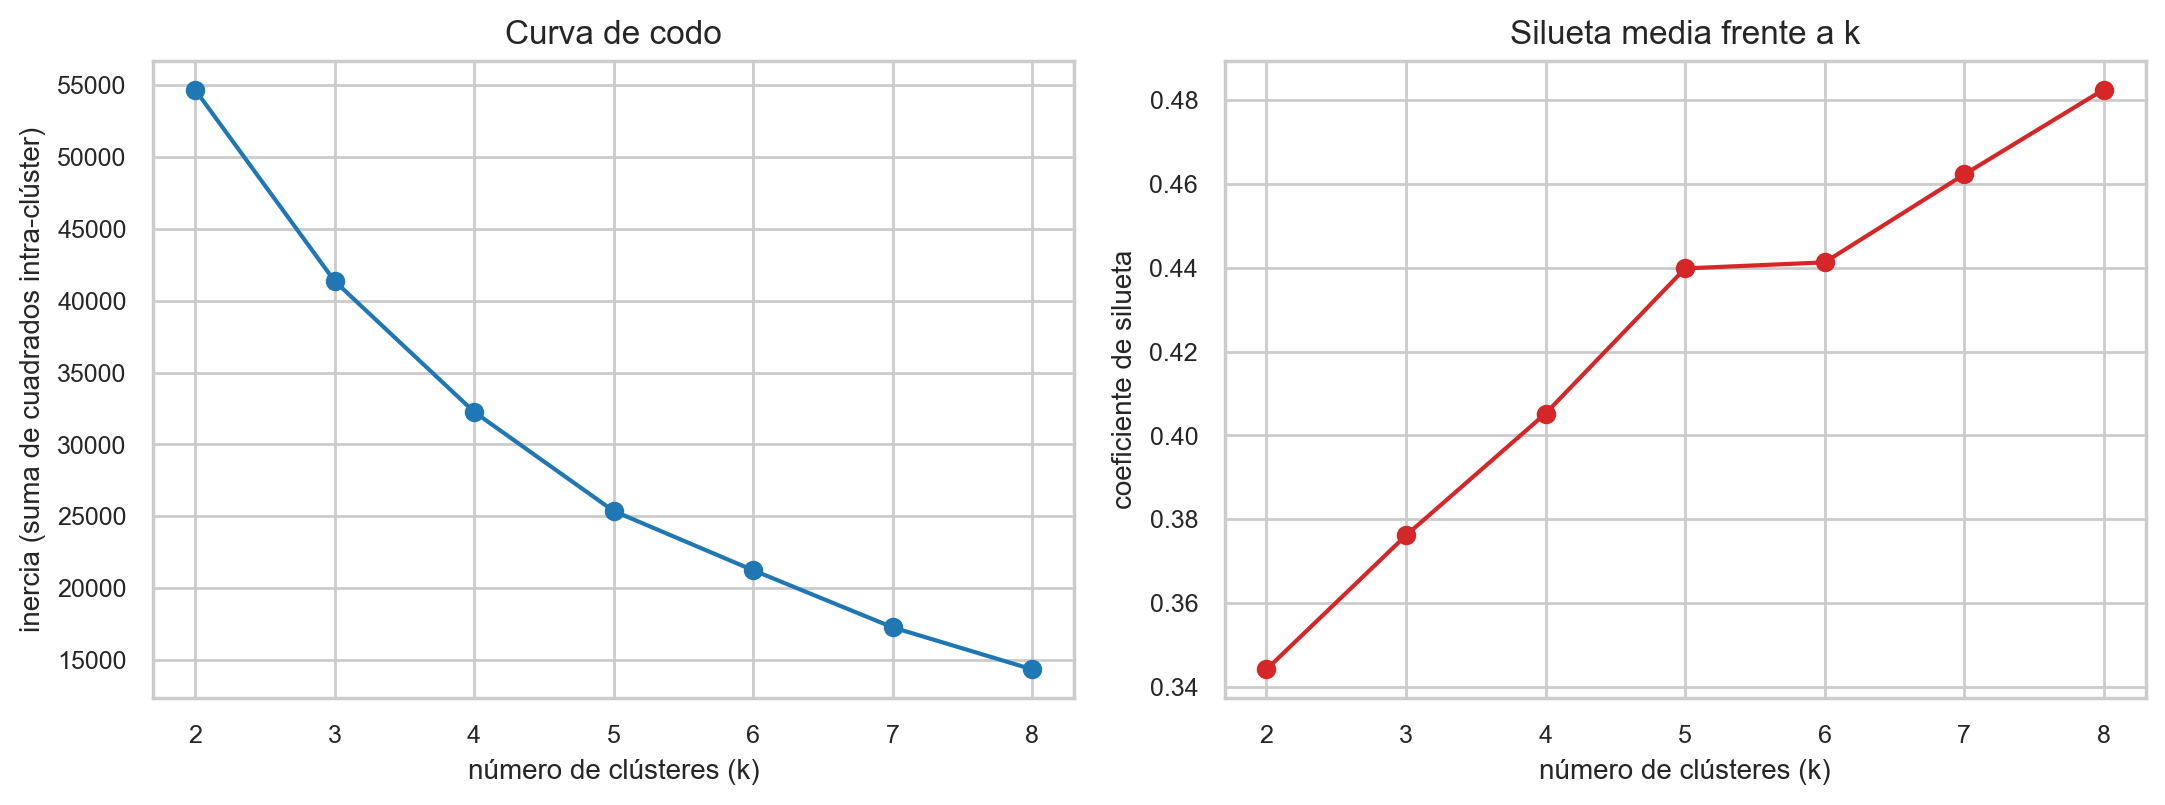

In [4]:
tabla_k = seg.evaluar_k(X_scaled)
print(tabla_k.to_string(index=False))

fig_k = rutas.FIGURAS / "nb05_seleccion_k_v1.png"
seg.plot_seleccion_k(tabla_k, fig_k)
display(Image(str(fig_k), width=850))

**Lectura y elección.** La silueta crece de forma monótona con k (de 0,34 a 0,48), sin un máximo
interior. Una silueta que sólo aumenta al subdividir es típica de datos sin una separación natural
fuerte y, por sí sola, **no es un criterio decisivo** para fijar k (llevada al extremo, premiaría
siempre el k más alto, sin ganancia interpretativa). La curva de codo, en cambio, muestra su mayor
caída relativa de inercia hasta k=3-4. Se elige **k = 3** por interpretabilidad: produce tres
perfiles nítidos y accionables, mientras que k mayores subdividen sin añadir una historia operativa
clara. Siguiendo la heurística habitual de que una silueta superior a 0,3 indica una estructura
razonable, el valor a k=3 (≈0,38) es suficiente y no obliga a recurrir a una mezcla gaussiana (GMM).

K-means con k=3. Tamaños de clúster:
0    7228
1    8029
2    6073


18:41:41 [INFO] PCA guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb05_pca_clusters_v1.png.


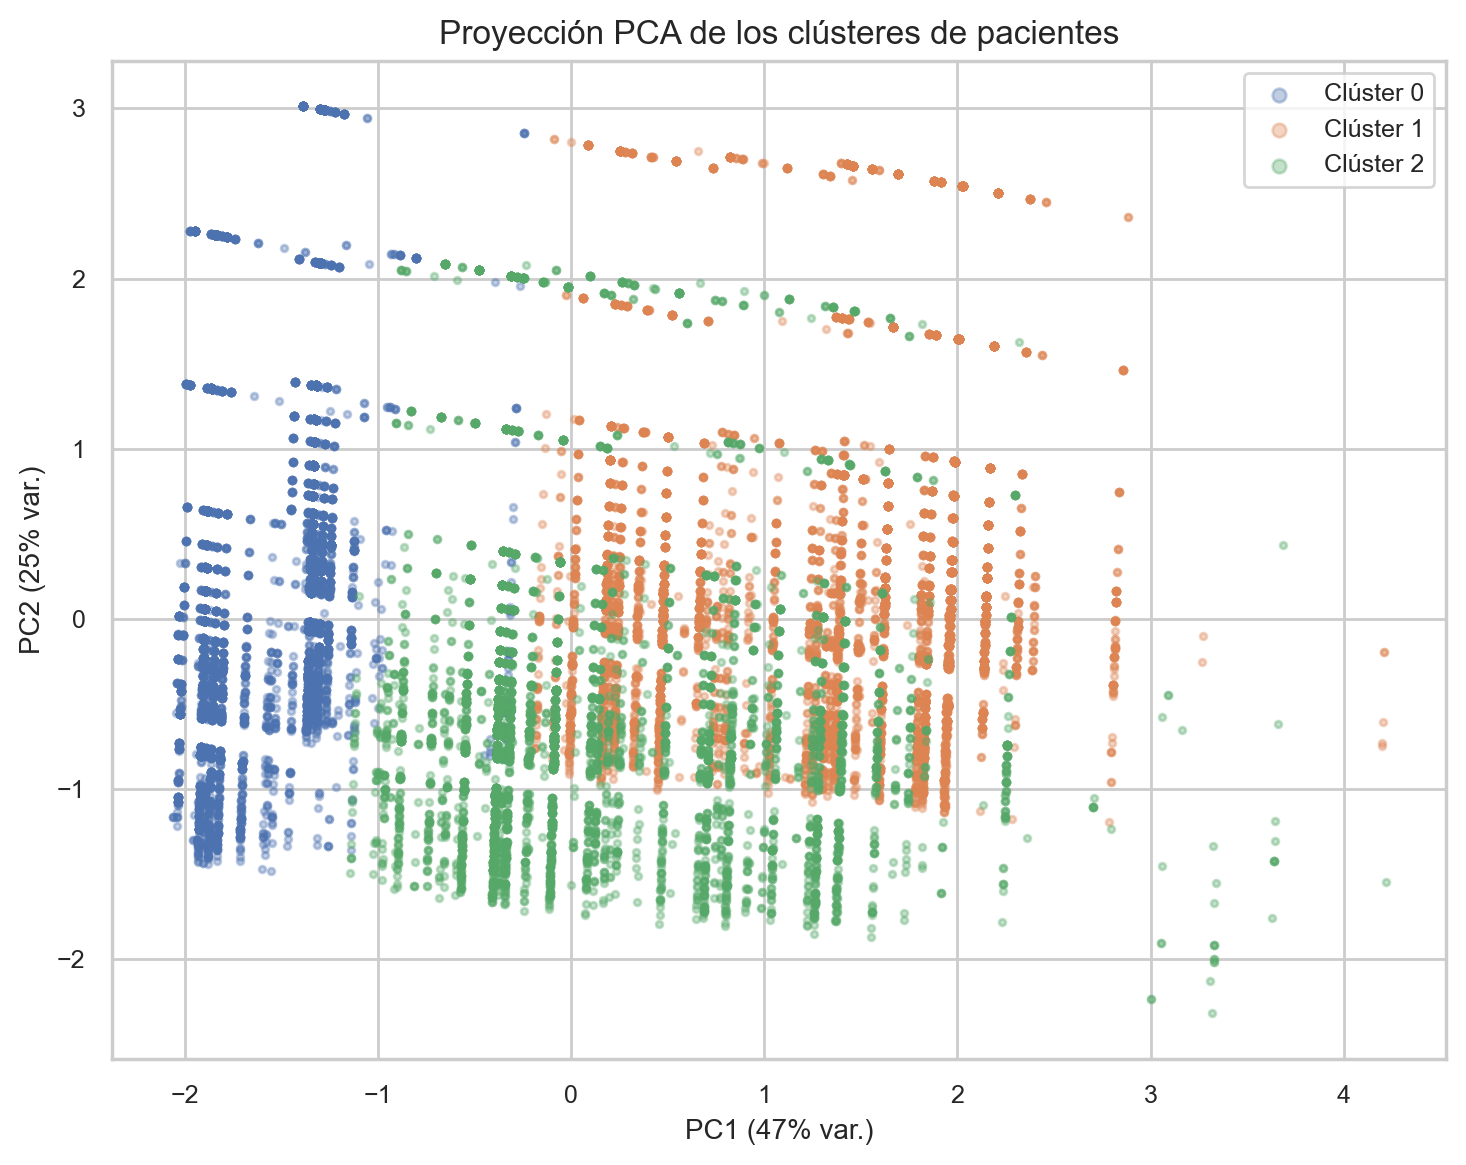

In [5]:
K = 3
labels, modelo_km = seg.ajustar_kmeans(X_scaled, K)
df["cluster"] = labels
print(f"K-means con k={K}. Tamaños de clúster:")
print(pd.Series(labels).value_counts().sort_index().to_string())

fig_pca = rutas.FIGURAS / "nb05_pca_clusters_v1.png"
seg.plot_pca(X_scaled, labels, fig_pca)
display(Image(str(fig_pca), width=650))

## 4. Perfilado de los clústeres

Cada clúster se describe con las variables crudas (que no intervinieron en el ajuste) y se le
asigna una etiqueta de negocio.

In [6]:
perfil = seg.perfilar_clusters(df, labels)
# Volumen de inasistencias esperado por clúster (tamaño × no-show observado)
perfil["noshows_esperados"] = (perfil["n"] * perfil["noshow_observado"]).round(0).astype(int)
display(perfil)

ruta_perfil = rutas.REPORTES / "nb05_perfil_clusters_v1.csv"
perfil.to_csv(ruta_perfil, index=False)
print(f"Perfil guardado en {ruta_perfil.name}")

,cluster,n,prob_noshow_media,noshow_observado,lead_time_medio,edad_media,pct_primera_visita,prior_noshow_medio,comorbilidades_media,pct_sms,noshows_esperados
0,0,7228,0.0323,0.0349,0.0440,37.3545,0.49,0.1405,0.3383,0.0044,252
1,1,8029,0.2702,0.2723,21.2649,38.9983,1.00,NaN,0.3110,0.7201,2186
2,2,6073,0.2482,0.2534,8.5238,39.6717,0.00,0.2305,0.3675,0.5949,1539


Perfil guardado en nb05_perfil_clusters_v1.csv


In [7]:
# Etiqueta de negocio por regla sobre el perfil (robusta a la numeración de K-means)
def etiquetar(fila):
    if fila["prob_noshow_media"] < 0.10:
        return "Bajo riesgo · mismo día"
    if fila["pct_primera_visita"] > 0.5:
        return "Alto riesgo · primera visita · alta antelación"
    return "Alto riesgo · recurrente · antelación media"

perfil["etiqueta"] = perfil.apply(etiquetar, axis=1)
assert perfil["etiqueta"].nunique() == len(perfil), \
    "etiquetas duplicadas: revisar la regla de etiquetado frente al perfil"
mapa_etiquetas = dict(zip(perfil["cluster"], perfil["etiqueta"]))
for _, f in perfil.iterrows():
    print(f"Clúster {f['cluster']} — {f['etiqueta']}")
    print(f"    n={f['n']:,}  prob. no-show={f['prob_noshow_media']:.1%}  "
          f"no-show obs.={f['noshow_observado']:.1%}  antelación={f['lead_time_medio']:.1f} d  "
          f"primera visita={f['pct_primera_visita']:.0%}  SMS={f['pct_sms']:.0%}")
    print(f"    inasistencias esperadas/periodo ≈ {f['noshows_esperados']:,}")

Clúster 0 — Bajo riesgo · mismo día
    n=7,228  prob. no-show=3.2%  no-show obs.=3.5%  antelación=0.0 d  primera visita=49%  SMS=0%
    inasistencias esperadas/periodo ≈ 252
Clúster 1 — Alto riesgo · primera visita · alta antelación
    n=8,029  prob. no-show=27.0%  no-show obs.=27.2%  antelación=21.3 d  primera visita=100%  SMS=72%
    inasistencias esperadas/periodo ≈ 2,186
Clúster 2 — Alto riesgo · recurrente · antelación media
    n=6,073  prob. no-show=24.8%  no-show obs.=25.3%  antelación=8.5 d  primera visita=0%  SMS=59%
    inasistencias esperadas/periodo ≈ 1,539


**Lectura.** Los tres perfiles se separan sobre todo por antelación y riesgo:

- **Bajo riesgo · mismo día**: citas concertadas para el mismo día, no-show ~3%. Apenas
  recibieron SMS y apenas generan inasistencias — no son el objetivo de la intervención.
- **Alto riesgo · primera visita · alta antelación**: pacientes nuevos con ~21 días de
  antelación y no-show ~27%. Concentran el mayor volumen de inasistencias.
- **Alto riesgo · recurrente · antelación media**: pacientes con historial, ~8-9 días de
  antelación y no-show ~25%.

La antelación reaparece como el eje dominante, coherente con su papel en los Notebooks 02-04.

El clúster de primera visita no presenta tasa de no-show previa (`prior_noshow_rate` aparece como `NaN` en el perfil) porque está formado al 100% por primeras visitas observadas: por definición carecen de historial anterior dentro de la ventana de datos (censura por la izquierda).

## 5. El envío de SMS por clúster (comparación descriptiva)

Para cuantificar si el SMS se está repartiendo de forma eficiente, se observa la tasa de no-show
por brazo de SMS dentro de cada clúster. **Es la comparación cruda, sin ajustar**: igual que en el
Notebook 02, está sujeta al sesgo de selección del envío (el SMS se mandó sobre todo a citas de
mayor antelación y riesgo), por lo que se interpreta de forma descriptiva, nunca causal.

In [8]:
resumen_sms = seg.resumen_sms_por_cluster(df, labels)
resumen_sms["etiqueta"] = resumen_sms["cluster"].map(mapa_etiquetas)
display(resumen_sms)

,cluster,n_sms,n_no_sms,noshow_sms,noshow_no_sms,dif_observada_pp,etiqueta
0,0,32,7196,0.1562,0.0343,12.1925,Bajo riesgo · mismo día
1,1,5782,2247,0.2700,0.2781,-0.8173,Alto riesgo · primera visita · alta antelación
2,2,3613,2460,0.2552,0.2508,0.4377,Alto riesgo · recurrente · antelación media


**Lectura.** El SMS está fuertemente concentrado en los clústeres de alta antelación (con
coberturas en torno al 60-72%) y casi ausente en el de mismo día (<1%). La diferencia cruda de
no-show entre quienes recibieron SMS y quienes no es positiva o nula dentro de cada clúster —el
mismo patrón contraintuitivo del Notebook 02—, reflejo de que el SMS se dirigió a las citas de
mayor riesgo basal, no de que el recordatorio sea perjudicial.

## 6. ¿Efecto causal por clúster?

Una extensión natural sería estimar el efecto causal (ATE) del SMS dentro de cada clúster. No se
reporta como estimación causal por una razón de fondo: el Notebook 04 mostró que la positividad
está estructuralmente rota a nivel de población (la asignación del SMS es cuasi-determinista en la
antelación), y la estimación global ni siquiera es robusta a la especificación. Restringir el
mismo modelo a subgrupos no resuelve ese problema —lo agrava, al reducir el solape y el tamaño
muestral—, así que un ATE por clúster no sería creíble. Se reportan, por tanto, **el riesgo
observado y el potencial de inasistencias por clúster** (secciones 4-5) como base de priorización,
y el efecto del SMS se trata a nivel de servicio con la evidencia experimental que alimenta el
Notebook 06.

## 7. Implicación: el SMS uniforme es subóptimo

Las inasistencias no se reparten por igual. El clúster de bajo riesgo (mismo día) genera muy
pocas y casi no necesita recordatorio; los dos clústeres de alta antelación concentran la
inmensa mayoría del volumen recuperable. Una política que envíe el SMS a toda la agenda gasta
presupuesto de comunicación en citas que apenas fallan, mientras que **priorizar por riesgo
predicho y antelación** dirige el esfuerzo donde está el valor. Esta segmentación es la entrada
natural de los escenarios "dirigido" del modelo económico (Notebook 06): el clúster define la
fracción de la agenda sobre la que se aplica la intervención.

In [9]:
total_noshows = int((df["Showed_up"] == 0).sum())
alto_riesgo = perfil[perfil["prob_noshow_media"] >= 0.10]
share_volumen = alto_riesgo["noshows_esperados"].sum() / total_noshows
share_agenda = alto_riesgo["n"].sum() / len(df)
print(f"Los clústeres de alto riesgo son el {share_agenda:.0%} de la agenda "
      f"y concentran el {share_volumen:.0%} de las inasistencias.")

Los clústeres de alto riesgo son el 66% de la agenda y concentran el 94% de las inasistencias.


## 8. Persistencia

In [10]:
ruta_asig = rutas.REPORTES / "nb05_clusters_v1.csv"
seg.persistir_segmentacion(df, labels, ruta_asig)

sidecar = {
    "notebook": "05_segmentacion_pacientes",
    "n_citas": int(len(df)),
    "conjunto": "test (con probabilidad calibrada de NB03)",
    "k_elegido": int(K),
    "criterio_k": "codo + interpretabilidad (silueta monótona, sin máximo)",
    "silueta_k": float(tabla_k.loc[tabla_k['k'] == K, 'silueta'].iloc[0]),
    "features_clustering": seg.FEATURES_CLUSTERING,
    "perfil": perfil.to_dict(orient="records"),
    "resumen_sms_por_cluster": resumen_sms.to_dict(orient="records"),
    "ate_por_cluster": ("No estimado como cantidad causal: la positividad rota a nivel de "
                        "población (NB04) no se resuelve en subgrupos. Se reporta riesgo y "
                        "potencial observados."),
    "share_inasistencias_alto_riesgo": float(share_volumen),
}
seg.persistir_sidecar(sidecar, rutas.REPORTES / "nb05_metadatos_v1.json")
print("Sidecar guardado.")

18:41:41 [INFO] Asignación de clústeres guardada en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/reportes/nb05_clusters_v1.csv (21330 filas).


18:41:41 [INFO] Sidecar guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/reportes/nb05_metadatos_v1.json.


Sidecar guardado.


## 9. Conclusiones

1. Tres perfiles nítidos emergen de las citas de test: uno de bajo riesgo (mismo día) y dos de
   alto riesgo y alta antelación, separados por si el paciente es nuevo o recurrente.
2. Las inasistencias se concentran en los clústeres de alta antelación; el de mismo día apenas
   contribuye. Un envío uniforme de SMS es, por tanto, ineficiente.
3. No se reporta un ATE causal por clúster: la falta de positividad documentada en el Notebook 04
   no se resuelve en subgrupos. La segmentación se usa para **priorizar** (quién), no para
   reestimar el efecto (cuánto), que se aborda con literatura en el Notebook 06.
4. La asignación de clúster por cita queda persistida como entrada de los escenarios dirigidos
   del modelo económico.

In [11]:
assert df["cluster"].nunique() == K, "número de clústeres inesperado"
assert not df[seg.FEATURES_CLUSTERING].isna().any().any(), "NaN en variables de clustering"
assert "SMS_received" not in seg.FEATURES_CLUSTERING, "el tratamiento no debe definir clústeres"
print("Checklist NB05: OK")
print("NB05 completo.")

Checklist NB05: OK
NB05 completo.
